In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.spatial.distance import squareform, cosine, pdist

sns.set_style()

## Read spectra data

In [2]:
path_to_data12 = "../1data_derivation/dataset/MutSpecVertebrates12.csv.gz"
path_to_data192 = "../1data_derivation/dataset/MutSpecVertebrates192.csv.gz"

mutspec192 = pd.read_csv(path_to_data192)
mutspec12 = pd.read_csv(path_to_data12)
print(mutspec192.shape, mutspec192.shape[0] / 192)
mutspec192.head()

(550272, 7) 2866.0


,Gene,Class,Species,Mut,Observed,Expected,MutSpec
0,CO1,Mammalia,Crocuta_crocuta,A[A>C]A,NaN,0.000000,0.0
1,CO1,Mammalia,Crocuta_crocuta,A[A>C]C,NaN,0.000000,0.0
2,CO1,Mammalia,Crocuta_crocuta,A[A>C]G,NaN,0.000000,0.0
3,CO1,Mammalia,Crocuta_crocuta,A[A>C]T,NaN,0.000000,0.0
4,CO1,Mammalia,Crocuta_crocuta,C[A>C]A,NaN,13.666667,0.0


### PCA on 12-component mutation spectra

In [3]:
mutspec12wide = mutspec12.pivot(
    index=['Class', 'Species', 'Gene'], 
    columns='Mut', values='MutSpec')
mutspec12wide

Mut                                                 A>C       A>G       A>T  \
Class       Species                      Gene                                 
Actinopteri Abbottina_rivularis          Cytb  0.039747  0.172039  0.039737   
            Acanthopagrus_latus          Cytb  0.000000  0.152405  0.000000   
            Acanthopagrus_taiwanensis    Cytb  0.000000  0.274547  0.052746   
            Acentrogobius_janthinopterus Cytb  0.023318  0.118252  0.000000   
            Acheilognathus_barbatulus    Cytb  0.000000  0.079251  0.000000   
...                                                 ...       ...       ...   
Mammalia    Zapus_princeps               Cytb  0.015633  0.067736  0.034381   
            Zapus_trinotatus             Cytb  0.000000  0.069746  0.033606   
            Ziphius_cavirostris          CO1   0.020102  0.123336  0.000000   
                                         Cytb  0.000000  0.039097  0.000000   
                                         ND2   0.018837  0.009400  0.009626   

Mut                                                 C>A       C>G       C>T  \
Class       Species                      Gene                                 
Actinopteri Abbottina_rivularis          Cytb  0.070087  0.000000  0.088995   
            Acanthopagrus_latus          Cytb  0.014289  0.028576  0.134607   
            Acanthopagrus_taiwanensis    Cytb  0.000000  0.000000  0.159206   
            Acentrogobius_janthinopterus Cytb  0.025166  0.000000  0.071199   
            Acheilognathus_barbatulus    Cytb  0.053767  0.000000  0.330116   
...                                                 ...       ...       ...   
Mammalia    Zapus_princeps               Cytb  0.039759  0.005267  0.128846   
            Zapus_trinotatus             Cytb  0.028589  0.000000  0.214301   
            Ziphius_cavirostris          CO1   0.000000  0.000000  0.153457   
                                         Cytb  0.000000  0.000000  0.066581   
                                         ND2   0.000000  0.013021  0.068297   

Mut                                                 G>A       G>C       G>T  \
Class       Species                      Gene                                 
Actinopteri Abbottina_rivularis          Cytb  0.264176  0.000000  0.147344   
            Acanthopagrus_latus          Cytb  0.472166  0.000000  0.000000   
            Acanthopagrus_taiwanensis    Cytb  0.296151  0.000000  0.000000   
            Acentrogobius_janthinopterus Cytb  0.573362  0.000000  0.000000   
            Acheilognathus_barbatulus    Cytb  0.493858  0.000000  0.000000   
...                                                 ...       ...       ...   
Mammalia    Zapus_princeps               Cytb  0.499851  0.040391  0.020304   
            Zapus_trinotatus             Cytb  0.434300  0.000000  0.000000   
            Ziphius_cavirostris          CO1   0.526546  0.000000  0.000000   
                                         Cytb  0.730006  0.000000  0.000000   
                                         ND2   0.782317  0.000000  0.000000   

Mut                                                 T>A       T>C       T>G  
Class       Species                      Gene                                
Actinopteri Abbottina_rivularis          Cytb  0.000000  0.088788  0.089086  
            Acanthopagrus_latus          Cytb  0.000000  0.197957  0.000000  
            Acanthopagrus_taiwanensis    Cytb  0.000000  0.217350  0.000000  
            Acentrogobius_janthinopterus Cytb  0.000000  0.188703  0.000000  
            Acheilognathus_barbatulus    Cytb  0.000000  0.043008  0.000000  
...                                                 ...       ...       ...  
Mammalia    Zapus_princeps               Cytb  0.021256  0.118071  0.008504  
            Zapus_trinotatus             Cytb  0.023390  0.196068  0.000000  
            Ziphius_cavirostris          CO1   0.000000  0.176559  0.000000  
                                         Cytb  0.000000  0

In [ ]:
from sklearn.decomposition import PCA

X = mutspec12wide.copy()
xvars = X.columns.values

labels_df = mutspec12wide.index.to_frame(index=False).astype('category')
class_data = labels_df['Class'].cat.codes.values
class_names = {i:s for i,s in enumerate(labels_df['Class'].cat.categories)}
gene_data = labels_df['Gene'].cat.codes.values
gene_names = {i:s for i,s in enumerate(labels_df['Gene'].cat.categories)}

pca = PCA(12)
X_pca = pca.fit_transform(X)
X_pca_df = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(X_pca.shape[1])])
X_pca_df.head(2)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12
0,-0.169136,-0.178320,0.008086,0.024672,0.149806,0.045365,-0.007543,0.072562,0.015912,0.019325,-0.019776,-8.326673e-16
1,-0.016873,-0.004252,0.006557,0.065415,-0.011242,-0.018891,-0.012773,-0.005286,0.001354,-0.011231,0.024202,5.551115e-17


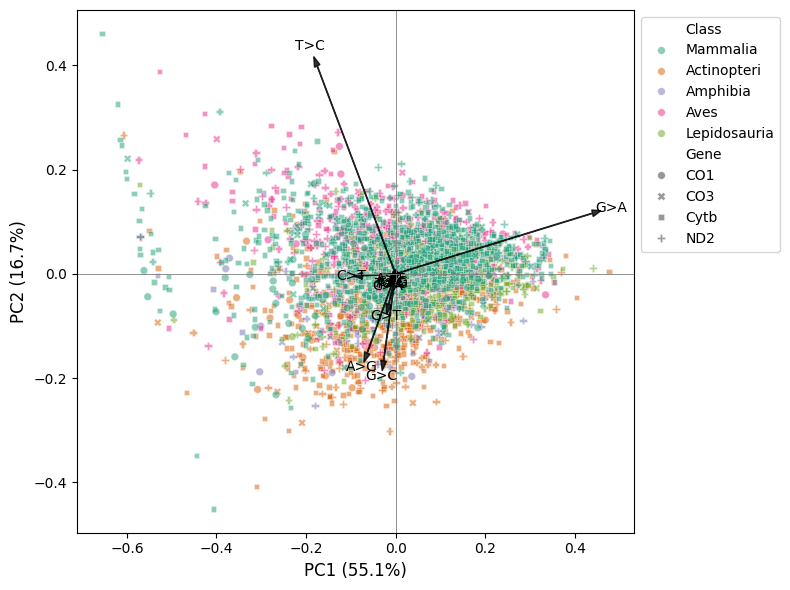

In [83]:
fig, ax = plt.subplots(figsize=(8, 6))
cmap = plt.cm.get_cmap('tab10')

sns.scatterplot(X_pca_df, x='PC1', y='PC2', hue=labels_df['Class'], style=labels_df['Gene'], 
                palette='Dark2', s=30, alpha=0.5, ax=ax,
                hue_order=['Mammalia', 'Actinopteri', 'Amphibia', 'Aves', 'Lepidosauria'],
)

# prepare loadings (features -> arrows)
loadings = pca.components_.T  # shape: (n_features, n_components)
xs = loadings[:, 0]
ys = loadings[:, 1]

# scale loadings to match score spread
score_extent = np.max(np.abs(X_pca[:, :2]))
loading_extent = max(np.max(np.abs(xs)), np.max(np.abs(ys)))
scale = (score_extent / loading_extent) * 0.7

# draw arrows and labels for each variable
for i, (lx, ly) in enumerate(zip(xs, ys)):
    ax.arrow(0, 0, lx * scale, ly * scale,
             color='black', alpha=0.8,
             length_includes_head=True, head_width=0.02 * score_extent)
    ax.text(lx * scale * 1.05, ly * scale * 1.05, xvars[i],
            fontsize=10, ha='center', va='center', color='black')

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)", fontsize=12)
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)", fontsize=12)
ax.axhline(0, color='gray', lw=0.6)
ax.axvline(0, color='gray', lw=0.6)
ax.legend(frameon=True, bbox_to_anchor=(1, 1), loc='upper left')
plt.tight_layout()
plt.show()

(<Axes: xlabel='PC1', ylabel='PC2'>,)

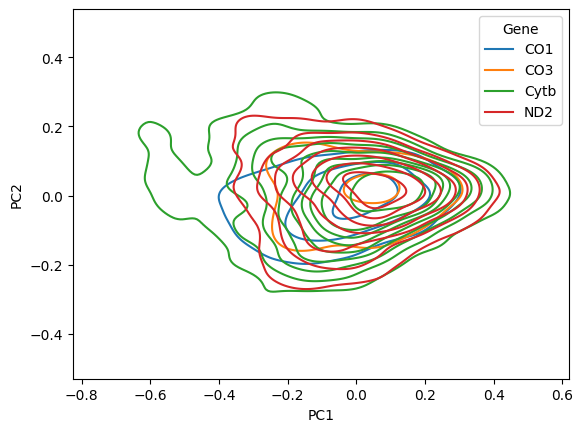

In [84]:
# any gene have same spectrum
sns.kdeplot(X_pca_df, x='PC1', y='PC2', hue=labels_df['Gene']),# style=labels_df['Gene'],

(<Axes: xlabel='PC1', ylabel='PC2'>,)

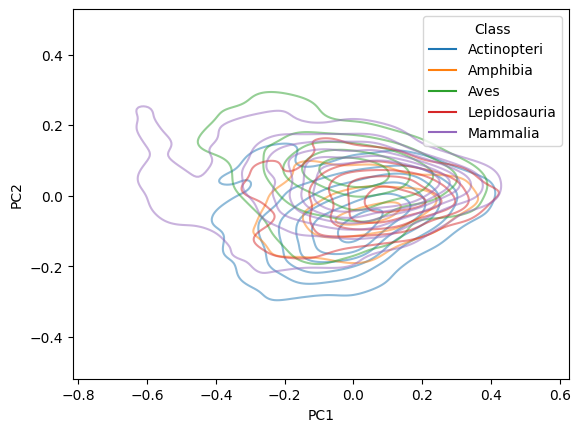

In [90]:
# there are class differences
sns.kdeplot(X_pca_df, x='PC1', y='PC2', hue=labels_df['Class'], alpha=0.5, levels=7),# style=labels_df['Gene'],

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Fit logistic regression models to predict Gene and Class from the mutation-spectrum features

# features and targets (use existing variables)
X_features = X.values  # as numpy array
y_gene = gene_data     # categorical codes for Gene
y_class = class_data   # categorical codes for Class

# scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)

# helper to fit/evaluate
def fit_eval(X, y, label_map, name):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42, stratify=y
    )
    clf = LogisticRegression(
        multi_class='multinomial', solver='lbfgs', #max_iter=2000
    )
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{name} prediction -- accuracy: {acc:.3f}")
    print("Classification report:")
    print(classification_report(y_test, y_pred, target_names=[label_map[i] for i in sorted(label_map)]))
    print("Confusion matrix:")
    print(confusion_matrix(y_test, y_pred))
    # quick cross-validated score
    cv_score = cross_val_score(clf, X, y, cv=5, scoring='accuracy').mean()
    print(f"5-fold CV accuracy (approx): {cv_score:.3f}\n")
    return clf

# Fit & evaluate for Gene
clf_gene = fit_eval(X_scaled, y_gene, gene_names, "Gene")

# Fit & evaluate for Class
clf_class = fit_eval(X_scaled, y_class, class_names, "Class")

Gene prediction -- accuracy: 0.590
Classification report:
              precision    recall  f1-score   support

         CO1       0.33      0.04      0.07        51
         CO3       0.00      0.00      0.00        28
        Cytb       0.59      0.99      0.74       425
         ND2       0.50      0.00      0.01       213

    accuracy                           0.59       717
   macro avg       0.36      0.26      0.21       717
weighted avg       0.52      0.59      0.45       717

Confusion matrix:
[[  2   0  49   0]
 [  0   0  28   0]
 [  4   0 420   1]
 [  0   0 212   1]]
5-fold CV accuracy (approx): 0.589

Class prediction -- accuracy: 0.545
Classification report:
              precision    recall  f1-score   support

 Actinopteri       0.63      0.68      0.65       173
    Amphibia       0.42      0.11      0.17        46
        Aves       0.51      0.31      0.39       128
Lepidosauria       0.42      0.14      0.21        95
    Mammalia       0.53      0.79      0.63   

In [63]:
from sklearn.dummy import DummyClassifier

def fit_eval_dummy(X, y, label_map, name):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42, stratify=y
    )
    clf = DummyClassifier(strategy='stratified', random_state=42)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{name} (dummy stratified) -- accuracy: {acc:.3f}")
    print("Classification report:")
    print(classification_report(y_test, y_pred, target_names=[label_map[i] for i in sorted(label_map)]))
    print("Confusion matrix:")
    print(confusion_matrix(y_test, y_pred))
    cv_score = cross_val_score(clf, X, y, cv=5, scoring='accuracy').mean()
    print(f"5-fold CV accuracy (approx): {cv_score:.3f}\n")
    return clf

# Compare dummy classifier to the logistic regression results
dummy_class = fit_eval_dummy(X_scaled, y_class, class_names, "Class")
dummy_gene = fit_eval_dummy(X_scaled, y_gene, gene_names, "Gene")

Class (dummy stratified) -- accuracy: 0.257
Classification report:
              precision    recall  f1-score   support

 Actinopteri       0.24      0.25      0.24       173
    Amphibia       0.00      0.00      0.00        46
        Aves       0.17      0.17      0.17       128
Lepidosauria       0.17      0.17      0.17        95
    Mammalia       0.38      0.37      0.38       275

    accuracy                           0.26       717
   macro avg       0.19      0.19      0.19       717
weighted avg       0.26      0.26      0.26       717

Confusion matrix:
[[ 43   7  35  18  70]
 [ 17   0   4   4  21]
 [ 30  12  22  18  46]
 [ 25   9  16  16  29]
 [ 67  16  49  40 103]]
5-fold CV accuracy (approx): 0.253

Gene (dummy stratified) -- accuracy: 0.445
Classification report:
              precision    recall  f1-score   support

         CO1       0.04      0.04      0.04        51
         CO3       0.15      0.14      0.15        28
        Cytb       0.58      0.58      0.58  

### PCA on 192-component mutation spectra

In [4]:
mutspec192wide = mutspec192.pivot(
    index=['Class', 'Species', 'Gene'], 
    columns='Mut', values='MutSpec')
mutspec192wide

Mut                                            A[A>C]A  A[A>C]C  A[A>C]G  \
Class       Species                      Gene                              
Actinopteri Abbottina_rivularis          Cytb      0.0      0.0      0.0   
            Acanthopagrus_latus          Cytb      0.0      0.0      0.0   
            Acanthopagrus_taiwanensis    Cytb      0.0      0.0      0.0   
            Acentrogobius_janthinopterus Cytb      0.0      0.0      0.0   
            Acheilognathus_barbatulus    Cytb      0.0      0.0      0.0   
...                                                ...      ...      ...   
Mammalia    Zapus_princeps               Cytb      0.0      0.0      0.0   
            Zapus_trinotatus             Cytb      0.0      0.0      0.0   
            Ziphius_cavirostris          CO1       0.0      0.0      0.0   
                                         Cytb      0.0      0.0      0.0   
                                         ND2       0.0      0.0      0.0   

Mut                                            A[A>C]T   A[A>G]A   A[A>G]C  \
Class       Species                      Gene                                
Actinopteri Abbottina_rivularis          Cytb      0.0  0.019057  0.000000   
            Acanthopagrus_latus          Cytb      0.0  0.009194  0.024203   
            Acanthopagrus_taiwanensis    Cytb      0.0  0.000000  0.000000   
            Acentrogobius_janthinopterus Cytb      0.0  0.000000  0.000000   
            Acheilognathus_barbatulus    Cytb      0.0  0.000000  0.000000   
...                                                ...       ...       ...   
Mammalia    Zapus_princeps               Cytb      0.0  0.002195  0.003150   
            Zapus_trinotatus             Cytb      0.0  0.000000  0.000000   
            Ziphius_cavirostris          CO1       0.0  0.000000  0.000000   
                                         Cytb      0.0  0.000000  0.014070   
                                         ND2       0.0  0.000000  0.000000   

Mut                                             A[A>G]G   A[A>G]T  A[A>T]A  \
Class       Species                      Gene                                
Actinopteri Abbottina_rivularis          Cytb  0.000000  0.000000      0.0   
            Acanthopagrus_latus          Cytb  0.018518  0.000000      0.0   
            Acanthopagrus_taiwanensis    Cytb  0.000000  0.083933      0.0   
            Acentrogobius_janthinopterus Cytb  0.000000  0.000000      0.0   
            Acheilognathus_barbatulus    Cytb  0.000000  0.000000      0.0   
...                                                 ...       ...      ...   
Mammalia    Zapus_princeps               Cytb  0.000000  0.003218      0.0   
            Zapus_trinotatus             Cytb  0.000000  0.000000      0.0   
            Ziphius_cavirostris          CO1   0.032349  0.000000      0.0   
                                         Cytb  0.000000  0.000000      0.0   
                                         ND2   0.000000  0.019706      0.0   

Mut                                            A[A>T]C  ...  T[T>A]G  T[T>A]T  \
Class       Species                      Gene           ...                     
Actinopteri Abbottina_rivularis          Cytb      0.0  ...      0.0      0.0   
            Acanthopagrus_latus          Cytb      0.0  ...      0.0      0.0   
            Acanthopagrus_taiwanensis    Cytb      0.0  ...      0.0      0.0   
            Acentrogobius_janthinopterus Cytb      0.0  ...      0.0      0.0   
            Acheilognathus_barbatulus    Cytb      0.0  ...      0.0      0.0   
...                                                ...  ...      ...      ...   
Mammalia    Zapus_princeps               Cytb      0.0  ...      0.0      0.0   
            Zapus_trinotatus             Cytb      0.0  ...      0.0      0.0   
            Ziphius_cavirostris          CO1       0.0  ...      0.0      0.0   
                                         Cytb      0.0  ...      0.0      0.0   
         

In [93]:
from sklearn.decomposition import PCA

X = mutspec192wide.copy()
xvars = X.columns.values

labels_df = mutspec192wide.index.to_frame(index=False).astype('category')
class_data = labels_df['Class'].cat.codes.values
class_names = {i:s for i,s in enumerate(labels_df['Class'].cat.categories)}
gene_data = labels_df['Gene'].cat.codes.values
gene_names = {i:s for i,s in enumerate(labels_df['Gene'].cat.categories)}

pca = PCA(12)
X_pca = pca.fit_transform(X)
X_pca_df = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(X_pca.shape[1])])
X_pca_df.head(2)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12
0,-0.029475,0.067426,-0.038955,-0.010892,-0.033495,0.050733,0.042392,0.048359,-0.018266,-0.001397,-0.013459,-0.023353
1,0.051032,-0.016872,-0.033709,-0.052983,0.014644,-0.035286,-0.092246,0.102480,-0.035065,-0.023546,0.020589,0.017851


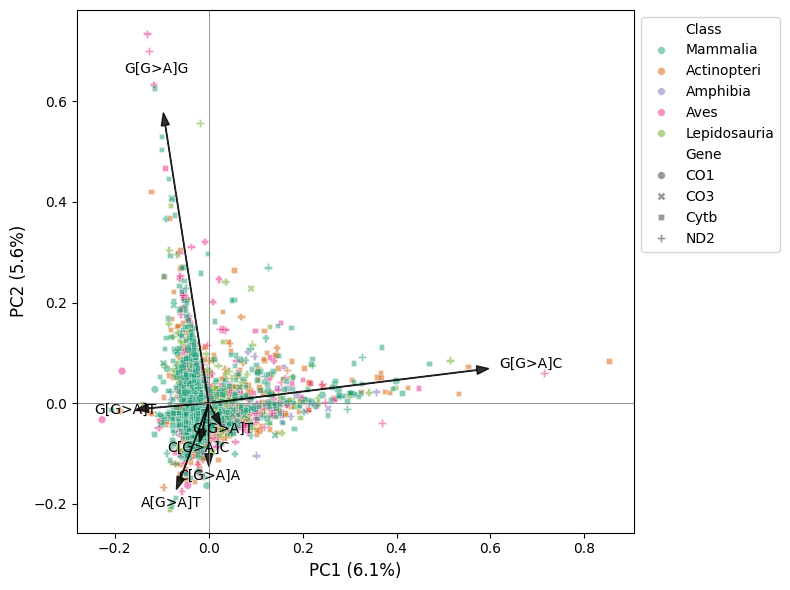

In [103]:
fig, ax = plt.subplots(figsize=(8, 6))
cmap = plt.cm.get_cmap('tab10')

sns.scatterplot(X_pca_df, x='PC1', y='PC2', hue=labels_df['Class'], style=labels_df['Gene'], 
                palette='Dark2', s=30, alpha=0.5, ax=ax,
                hue_order=['Mammalia', 'Actinopteri', 'Amphibia', 'Aves', 'Lepidosauria'],
)

# prepare loadings (features -> arrows)
loadings = pca.components_.T  # shape: (n_features, n_components)
xs = loadings[:, 0]
ys = loadings[:, 1]

# scale loadings to match score spread
score_extent = np.max(np.abs(X_pca[:, :2]))
loading_extent = max(np.max(np.abs(xs)), np.max(np.abs(ys)))
scale = (score_extent / loading_extent) * 0.7

# draw arrows and labels for each variable
for i, (lx, ly) in enumerate(zip(xs, ys)):
    if np.sqrt(lx**2 + ly**2) < 0.08:
        continue

    ax.arrow(0, 0, lx * scale, ly * scale,
             color='black', alpha=0.8,
             length_includes_head=True, head_width=0.02 * score_extent)
    ax.text(lx * scale * 1.15, ly * scale * 1.15, xvars[i],
            fontsize=10, ha='center', va='center', color='black')
    

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)", fontsize=12)
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)", fontsize=12)
ax.axhline(0, color='gray', lw=0.6)
ax.axvline(0, color='gray', lw=0.6)
ax.legend(frameon=True, bbox_to_anchor=(1, 1), loc='upper left')
plt.tight_layout()
plt.show()

(<Axes: xlabel='PC1', ylabel='PC2'>,)

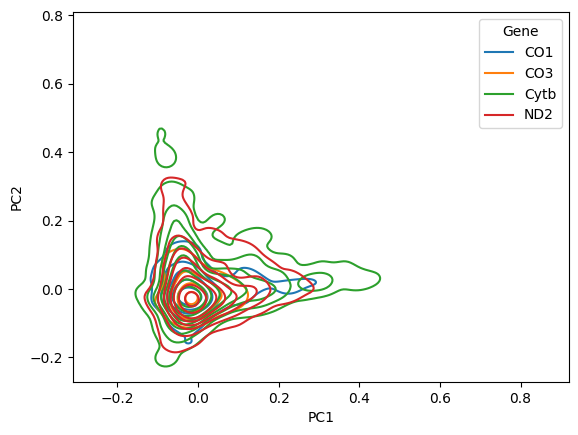

In [104]:
# any gene have same spectrum
sns.kdeplot(X_pca_df, x='PC1', y='PC2', hue=labels_df['Gene']),# style=labels_df['Gene'],

(<Axes: xlabel='PC1', ylabel='PC2'>,)

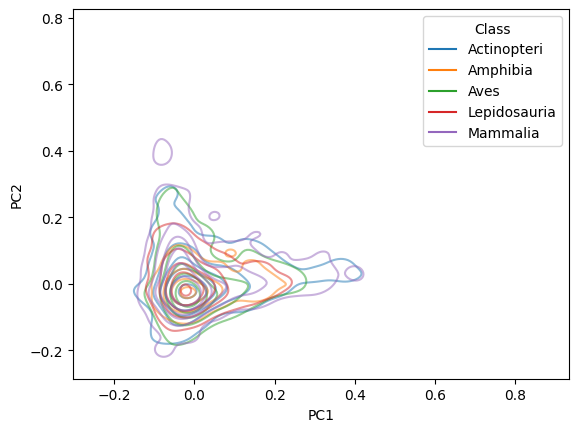

In [105]:
# there are class differences
sns.kdeplot(X_pca_df, x='PC1', y='PC2', hue=labels_df['Class'], alpha=0.5, levels=7),# style=labels_df['Gene'],

In [106]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Fit logistic regression models to predict Gene and Class from the mutation-spectrum features

# features and targets (use existing variables)
X_features = X.values  # as numpy array
y_gene = gene_data     # categorical codes for Gene
y_class = class_data   # categorical codes for Class

# scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)

# helper to fit/evaluate
def fit_eval(X, y, label_map, name):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42, stratify=y
    )
    clf = LogisticRegression(
        multi_class='multinomial', solver='lbfgs', #max_iter=2000
    )
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{name} prediction -- accuracy: {acc:.3f}")
    print("Classification report:")
    print(classification_report(y_test, y_pred, target_names=[label_map[i] for i in sorted(label_map)]))
    print("Confusion matrix:")
    print(confusion_matrix(y_test, y_pred))
    # quick cross-validated score
    cv_score = cross_val_score(clf, X, y, cv=5, scoring='accuracy').mean()
    print(f"5-fold CV accuracy (approx): {cv_score:.3f}\n")
    return clf

# Fit & evaluate for Gene
clf_gene = fit_eval(X_scaled, y_gene, gene_names, "Gene")

# Fit & evaluate for Class
clf_class = fit_eval(X_scaled, y_class, class_names, "Class")

Gene prediction -- accuracy: 0.580
Classification report:
              precision    recall  f1-score   support

         CO1       0.11      0.04      0.06        51
         CO3       0.05      0.04      0.04        28
        Cytb       0.65      0.81      0.72       425
         ND2       0.48      0.33      0.39       213

    accuracy                           0.58       717
   macro avg       0.32      0.30      0.30       717
weighted avg       0.54      0.58      0.55       717

Confusion matrix:
[[  2   2  37  10]
 [  2   1  17   8]
 [ 11  13 343  58]
 [  4   6 133  70]]
5-fold CV accuracy (approx): 0.555

Class prediction -- accuracy: 0.505
Classification report:
              precision    recall  f1-score   support

 Actinopteri       0.57      0.55      0.56       173
    Amphibia       0.18      0.15      0.17        46
        Aves       0.42      0.41      0.41       128
Lepidosauria       0.30      0.23      0.26        95
    Mammalia       0.59      0.67      0.63   

In [107]:
from sklearn.dummy import DummyClassifier

def fit_eval_dummy(X, y, label_map, name):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42, stratify=y
    )
    clf = DummyClassifier(strategy='stratified', random_state=42)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{name} (dummy stratified) -- accuracy: {acc:.3f}")
    print("Classification report:")
    print(classification_report(y_test, y_pred, target_names=[label_map[i] for i in sorted(label_map)]))
    print("Confusion matrix:")
    print(confusion_matrix(y_test, y_pred))
    cv_score = cross_val_score(clf, X, y, cv=5, scoring='accuracy').mean()
    print(f"5-fold CV accuracy (approx): {cv_score:.3f}\n")
    return clf

# Compare dummy classifier to the logistic regression results
dummy_class = fit_eval_dummy(X_scaled, y_class, class_names, "Class")
dummy_gene = fit_eval_dummy(X_scaled, y_gene, gene_names, "Gene")

Class (dummy stratified) -- accuracy: 0.257
Classification report:
              precision    recall  f1-score   support

 Actinopteri       0.24      0.25      0.24       173
    Amphibia       0.00      0.00      0.00        46
        Aves       0.17      0.17      0.17       128
Lepidosauria       0.17      0.17      0.17        95
    Mammalia       0.38      0.37      0.38       275

    accuracy                           0.26       717
   macro avg       0.19      0.19      0.19       717
weighted avg       0.26      0.26      0.26       717

Confusion matrix:
[[ 43   7  35  18  70]
 [ 17   0   4   4  21]
 [ 30  12  22  18  46]
 [ 25   9  16  16  29]
 [ 67  16  49  40 103]]
5-fold CV accuracy (approx): 0.253

Gene (dummy stratified) -- accuracy: 0.445
Classification report:
              precision    recall  f1-score   support

         CO1       0.04      0.04      0.04        51
         CO3       0.15      0.14      0.15        28
        Cytb       0.58      0.58      0.58  

## Cossim distributions

Mean cosine similarity (12 mut types): 0.87 ± 0.14
Mean cosine similarity (192 mut types): 0.21 ± 0.16


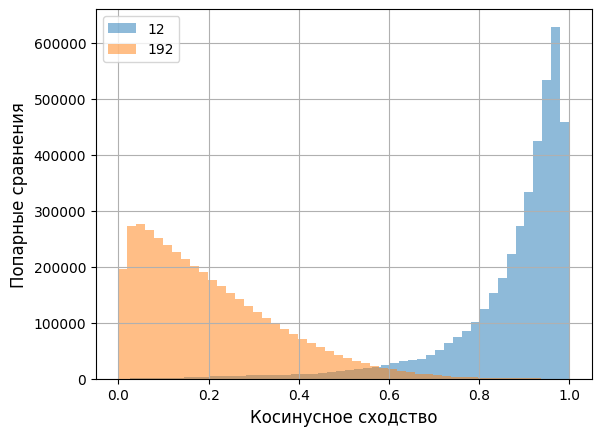

In [53]:
x = 1-pdist(mutspec12wide, 'cosine')
y = 1-pdist(mutspec192wide, 'cosine')
pd.Series(x).hist(bins=50, alpha=0.5, label='12')
pd.Series(y).hist(bins=50, alpha=0.5, label='192')
plt.legend()
plt.xlabel('Косинусное сходство', fontsize=12)
plt.ylabel('Попарные сравнения', fontsize=12)

print(f"Mean cosine similarity (12 mut types): {np.mean(x):.2f} ± {np.std(x):.2f}")
print(f"Mean cosine similarity (192 mut types): {np.mean(y):.2f} ± {np.std(y):.2f}")

Text(0, 0.5, 'Количество видов')

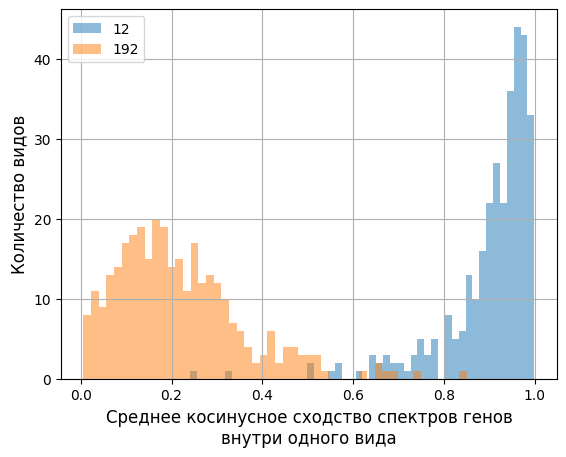

In [52]:
# species-specific gene spectra similarity

def gene_sim(df, func=np.mean):
    cs = 1-pdist(df.drop('Species', axis=1), 'cosine')
    return func(cs)

mutspec12wide.reset_index(level=1).groupby('Species').apply(gene_sim).hist(bins=50, alpha=0.5, label='12')
mutspec192wide.reset_index(level=1).groupby('Species').apply(gene_sim).hist(bins=50, alpha=0.5, label='192')
plt.legend()
plt.xlabel('Среднее косинусное сходство спектров генов\nвнутри одного вида', fontsize=12)
plt.ylabel('Количество видов', fontsize=12)